# **Cubo Gelatinoso -**  Aprendizado de Máquina

Prof. Dr. Daniel R. Cassar <br>
Aluno Giovanni A. Moreira (2610060) <br>
Setembro de 2026

## **1. Introdução**

Um algoritmo de aprendizado de máquina utiliza **dados** para induzir um **modelo preditivo**. Assim como uma função matemática recebe **x** e retorna **y**, um modelo preditivo recebe **dados** e, a partir deles, é capaz de retornar uma ou mais previsões. [1]

A contaminação por mercúrio em peixes é uma preocupação relevante de saúde pública e ambiental. O mercúrio se acumula ao longo da cadeia alimentar aquática, atingindo concentrações mais altas em peixes predadores, sendo que seu consumo está associado a riscos neurológicos, especialmente em gestantes e crianças [6]. Monitorar essa contaminação, como faz a *National Coastal Condition Assessment* da EPA, é importante tanto para avaliação de risco à saúde humana quanto para o monitoramento da qualidade ambiental de corpos d'água.

O **$k$-Nearest Neighbours ($k$-NN)** é um dos muitos algoritmos criados dentro da área de aprendizado de máquina que, segundo Cassar (2026), "[...] é um algoritmo de aprendizado de máquina baseado na hipótese que dados similares ocupam regiões próximas no espaço de entrada (isto é, no espaço dos atributos).". 

Neste *Python notebook*, o algoritmo *$k$-NN* é utilizado para **induzir um modelo** que seja capaz de **estimar a quantidade de mercúrio em peixes**. Para isso, foram avaliados **33 conjuntos de hiperparâmetros** - obtidos pela variação no número de vizinhos considerado ($k$) e a métrica de distância utilizada, euclidiana, manhattan e chebyshev - em dados **com e sem normalização**. Por fim, o desempenho de cada configuração foi avaliado por meio do **erro absoluto médio** (MAE) e **R²**, afim de identificar qual **combinação de hiperparâmetros** apresentou melhores resultados.

## **2. Metodologia**

O *dataset* sobre *fish tissue plugs* escolhido para essa atividade é proveniente da *National Aquatic Research Surveys (NARS)*, retirado do site *U.S. Environmental Protection Agency (U.S. EPA)*. Ele conta com 40 atributos, sendo 11 deles numéricos e 29 categóricos, e 910 exemplos de peixe [5].

### *2.1. Carregamento, tratamento e tradução dos dados*

In [1]:
#Importação da biblioteca pandas
import pandas as pd

A célula abaixo extrai os dados de um arquivo .csv por meio da biblioteca **Pandas**.

In [2]:
# Extrai o DataFrame do arquivo .csv presente no repositório
df_inicial = pd.read_csv("ncca20_hg_fishplug.csv")

# Mostra, por meio de uma lista, quais são as colunas do DF
print(list(df_inicial.columns))

['PUBLICATION_DATE', 'UID', 'UNIQUE_ID', 'SITE_ID', 'VISIT_NO', 'DATE_COL', 'ACTUAL_DATE', 'PSTL_CODE', 'WTBDY_TYPE', 'NCCA_REG', 'GREAT_LAKE', 'LAB', 'SAMPLE_TYPE', 'MATRIX', 'ANALYTE', 'SAM_CODE', 'CAS_NO', 'BATCH_ID', 'SAMPLE_ID', 'LAB_SAMPLE_ID', 'RESULT', 'RESULT_UNITS', 'MDL', 'RL', 'HOLDING_TIME', 'DILUTION', 'ARRIVAL_TEMP', 'CONDITION_CODE', 'DATE_ANALYZED', 'METHOD', 'INSTRUMENT', 'CONDITION_COMMENT', 'FROM_FTIS', 'NAME_SCI', 'LENGTH_1', 'LENGTH_2', 'WEIGHT_1', 'WEIGHT_2', 'NARS_FLAG', 'NARS_COMMENT']


Como o *dataset* escolhido apresenta alguns atributos categóricos nominais que dizem respeito apenas a identificação da amostra - o que não é tão interessante para indução de modelos preditivos - por isso, eles serão filtrados do *data frame*.

In [3]:
# Define as colunas que serão removidas
colunas_para_remocao = [
"PUBLICATION_DATE", "UID", "UNIQUE_ID", "SITE_ID", "VISIT_NO", 
"LAB", "SAMPLE_TYPE", "MATRIX", "ANALYTE", "SAM_CODE",
"CAS_NO", "BATCH_ID", "SAMPLE_ID", "LAB_SAMPLE_ID", "RESULT_UNITS",
"MDL", "RL", "HOLDING_TIME", "DILUTION", "ARRIVAL_TEMP",
"CONDITION_CODE", "DATE_ANALYZED", "METHOD", "INSTRUMENT", "CONDITION_COMMENT", 
"FROM_FTIS", "LENGTH_2", "WEIGHT_2", "NARS_FLAG", "NARS_COMMENT"
]

# "Dropa" (remove) as colunas do data frame
df_filtrado = df_inicial.drop(colunas_para_remocao, axis=1)

# Imprime o data frame até o atual momento
df_filtrado

,DATE_COL,ACTUAL_DATE,PSTL_CODE,WTBDY_TYPE,NCCA_REG,GREAT_LAKE,RESULT,NAME_SCI,LENGTH_1,WEIGHT_1
0,6/1/2020,NaN,TX,MARINE,Gulf,NaN,11.5,Micropogonias undulatus,250.0,200
1,6/2/2020,NaN,MI,GREAT_LAKES,Great Lakes,Lake Superior,190.0,Lota lota,434.0,540
2,6/3/2020,NaN,TX,MARINE,Gulf,NaN,17.5,Micropogonias undulatus,164.0,80
3,6/3/2020,NaN,MI,GREAT_LAKES,Great Lakes,Lake Superior,84.5,Catostomus catostomus,448.0,900
4,6/2/2020,NaN,TX,MARINE,Gulf,NaN,18.0,Micropogonias undulatus,175.0,80
...,...,...,...,...,...,...,...,...,...,...
905,7/17/2022,9/20/2020,MI,GREAT_LAKES,Great Lakes,Lake Michigan,58.1,Prosopium cylindraceum,482.0,1080
906,7/17/2022,9/20/2020,MI,GREAT_LAKES,Great Lakes,Lake Michigan,56.3,Prosopium cylindraceum,443.0,760
907,7/18/2022,9/20/2020,MI,GREAT_LAKES,Great Lakes,Lake Michigan,46.8,Prosopium cylindraceum,465.0,920
908,7/16/2022,9/19/2020,MI,GREAT_LAKES,Great Lakes,Lake Michigan,140.0,Salvelinus namaycush,628.0,4950


Sobraram 10 atributos, sendo um deles "*RESULT*", o target escolhido.

Ainda há um tratamento a ser feito referente as datas de coleta. Ambas colunas "DATE_COL" e "ACTUAL_DATE" mostram a data em que a coleta da amostra foi feita, porém, algumas delas da primeira coluna estão "erradas" (com um *gap* de até 2 anos). Os valores corretos estão presentes na segunda coluna, "ACTUAL_DATE"; por isso, todas as datas "erráticas" serão substituídas por seus correspondentes valores corretos.

In [4]:
# Preenche os valores NaN presentes em "ACTUAL_DATE" e atribui tudo isso a uma nova coluna
df_filtrado["REAL_DATE_COL"] = df_filtrado["ACTUAL_DATE"].fillna(df_filtrado["DATE_COL"])

# Tira as colunas antigas de data
df_corrigido2 = df_filtrado.drop(["ACTUAL_DATE", "DATE_COL"], axis=1)

# Imprime o data frame com data corrigida
df_corrigido2

,PSTL_CODE,WTBDY_TYPE,NCCA_REG,GREAT_LAKE,RESULT,NAME_SCI,LENGTH_1,WEIGHT_1,REAL_DATE_COL
0,TX,MARINE,Gulf,NaN,11.5,Micropogonias undulatus,250.0,200,6/1/2020
1,MI,GREAT_LAKES,Great Lakes,Lake Superior,190.0,Lota lota,434.0,540,6/2/2020
2,TX,MARINE,Gulf,NaN,17.5,Micropogonias undulatus,164.0,80,6/3/2020
3,MI,GREAT_LAKES,Great Lakes,Lake Superior,84.5,Catostomus catostomus,448.0,900,6/3/2020
4,TX,MARINE,Gulf,NaN,18.0,Micropogonias undulatus,175.0,80,6/2/2020
...,...,...,...,...,...,...,...,...,...
905,MI,GREAT_LAKES,Great Lakes,Lake Michigan,58.1,Prosopium cylindraceum,482.0,1080,9/20/2020
906,MI,GREAT_LAKES,Great Lakes,Lake Michigan,56.3,Prosopium cylindraceum,443.0,760,9/20/2020
907,MI,GREAT_LAKES,Great Lakes,Lake Michigan,46.8,Prosopium cylindraceum,465.0,920,9/20/2020
908,MI,GREAT_LAKES,Great Lakes,Lake Michigan,140.0,Salvelinus namaycush,628.0,4950,9/19/2020


Os atributo "**WTBDY_TYPE**" e "**GREAT_LAKE**" apresentam informações semelhantes. No entanto, enquanto o primeiro indica apenas o tipo de corpo da água em que o peixe foi capturado (marinho ou pluvial), o segundo fornece informações mais específicas sobre a região de origem da amostra. Dessa forma, os valores ausentes da coluna "**GREAT_LAKE**", presentes exclusivamente em registros classificados como "**MARINE**" em "**WTBDY_TYPE**", foram substituidos por "Ocean". Com isso, a *feature* "**WTBDY_TYPE**" será removida do *dataset* para as próximas etapas da análise.

In [5]:
# Preenche "Ocean" no lugar dos valores NaN em "NCCA_REG"
df_corrigido2["GREAT_LAKE"] = df_corrigido2["GREAT_LAKE"].fillna("Ocean")

# Tira a coluna "WTBDY_TYPE"
df_corrigido2 = df_corrigido2.drop(["WTBDY_TYPE"], axis=1)

# Imprime o dataset após as alterações
df_corrigido2

,PSTL_CODE,NCCA_REG,GREAT_LAKE,RESULT,NAME_SCI,LENGTH_1,WEIGHT_1,REAL_DATE_COL
0,TX,Gulf,Ocean,11.5,Micropogonias undulatus,250.0,200,6/1/2020
1,MI,Great Lakes,Lake Superior,190.0,Lota lota,434.0,540,6/2/2020
2,TX,Gulf,Ocean,17.5,Micropogonias undulatus,164.0,80,6/3/2020
3,MI,Great Lakes,Lake Superior,84.5,Catostomus catostomus,448.0,900,6/3/2020
4,TX,Gulf,Ocean,18.0,Micropogonias undulatus,175.0,80,6/2/2020
...,...,...,...,...,...,...,...,...
905,MI,Great Lakes,Lake Michigan,58.1,Prosopium cylindraceum,482.0,1080,9/20/2020
906,MI,Great Lakes,Lake Michigan,56.3,Prosopium cylindraceum,443.0,760,9/20/2020
907,MI,Great Lakes,Lake Michigan,46.8,Prosopium cylindraceum,465.0,920,9/20/2020
908,MI,Great Lakes,Lake Michigan,140.0,Salvelinus namaycush,628.0,4950,9/19/2020


Agora o nome das colunas será traduzido por preferência pessoal e para melhor compreensão ao longo do notebook.

In [6]:
# Cria uma lista com os nomes das colunas traduzidos
colunas_traduzidas = [
"Estado", "Região",
"Local de coleta", "Concentração de Hg (ng/g)", "Espécie",
"Comprimento (mm)", "Peso (g)", "Data de coleta"
]

# Traduz as colunas
df_corrigido2.columns = colunas_traduzidas

# Dropa os valores NaN
df_corrigido2 = df_corrigido2.dropna(axis=0)

df_corrigido2

,Estado,Região,Local de coleta,Concentração de Hg (ng/g),Espécie,Comprimento (mm),Peso (g),Data de coleta
0,TX,Gulf,Ocean,11.5,Micropogonias undulatus,250.0,200,6/1/2020
1,MI,Great Lakes,Lake Superior,190.0,Lota lota,434.0,540,6/2/2020
2,TX,Gulf,Ocean,17.5,Micropogonias undulatus,164.0,80,6/3/2020
3,MI,Great Lakes,Lake Superior,84.5,Catostomus catostomus,448.0,900,6/3/2020
4,TX,Gulf,Ocean,18.0,Micropogonias undulatus,175.0,80,6/2/2020
...,...,...,...,...,...,...,...,...
905,MI,Great Lakes,Lake Michigan,58.1,Prosopium cylindraceum,482.0,1080,9/20/2020
906,MI,Great Lakes,Lake Michigan,56.3,Prosopium cylindraceum,443.0,760,9/20/2020
907,MI,Great Lakes,Lake Michigan,46.8,Prosopium cylindraceum,465.0,920,9/20/2020
908,MI,Great Lakes,Lake Michigan,140.0,Salvelinus namaycush,628.0,4950,9/19/2020


In [7]:
df_corrigido2 = df_corrigido2.convert_dtypes()

df_corrigido2.dtypes

Estado                       string[python]
Região                       string[python]
Local de coleta              string[python]
Concentração de Hg (ng/g)           Float64
Espécie                      string[python]
Comprimento (mm)                    Float64
Peso (g)                     string[python]
Data de coleta               string[python]
dtype: object

Aqui temos um problema, atributos como Peso (g) e a Data de coleta são strings quando, na verdade, deveriam ser do seus respectivos tipos. Para corrigir isso o comando `to_numeric` e `to_datetime` é aplicado na próxima célula.

In [8]:
# Transforma as strings do atributo peso em float
df_corrigido2["Peso (g)"] = pd.to_numeric(df_corrigido2["Peso (g)"].astype(str).str.replace(",", ""))

# Transforma as strings do atributo data em um tipo mais adequado para manipulação
df_corrigido2["Data de coleta"] = pd.to_datetime(df_corrigido2["Data de coleta"])

### *2.2. Análise exploratória de dados e seleção de atributos*

A Análise Exploratória de Dados (AED) é uma prática fundamental para compreensão estatística de dados, com ela é possível compreender a estrutura dos dados, identificar determinados padrões, detectar de possíveis erros e, em um geral, obter informações relevantes para tomada de decisões e/ou ações sobre determinada problemática [2]. A AED presente nesta seção é essencial para a seleção de atributos para a indução do modelo preditivo.

Tendo como *target* a concentração de mercúrio por grama de amostra, busca-se checar a relação entre o alvo e os demais atributos pré-selecionados. Por isso, gráficos foram gerados para tornar visível a relação que as *features* possuem (ou não) com o *target*.

In [9]:
# Importação de bibliotecas para criação de gráficos
import seaborn as sns
import matplotlib.pyplot as plt

A primeira coisa a ser feita foi a utilização do comando `describe` a fim de que se tenha um panorama geral dos dados a serem trabalhados.

In [26]:
df_corrigido2.describe(include="all")

,Estado,Região,Local de coleta,Concentração de Hg (ng/g),Espécie,Comprimento (mm),Peso (g),Data de coleta,Espécie agrupada
count,905,905,905,905.0,905,905.0,905.000000,905,905
unique,27,5,6,<NA>,80,<NA>,NaN,NaN,25
top,MI,Northeast,Ocean,<NA>,Ariopsis felis,<NA>,NaN,NaN,Outras
freq,132,309,689,<NA>,152,<NA>,NaN,NaN,161
mean,NaN,NaN,NaN,117.747193,NaN,331.059779,541.213591,2020-10-09 13:17:10.276243200,NaN
min,NaN,NaN,NaN,3.92,NaN,110.0,34.000000,2020-06-01 00:00:00,NaN
25%,NaN,NaN,NaN,57.8,NaN,248.0,180.000000,2020-07-21 00:00:00,NaN
50%,NaN,NaN,NaN,91.5,NaN,304.0,340.000000,2020-08-18 00:00:00,NaN
75%,NaN,NaN,NaN,153.0,NaN,391.0,620.000000,2020-09-20 00:00:00,NaN
max,NaN,NaN,NaN,910.0,NaN,880.0,7740.000000,2022-07-12 00:00:00,NaN


Afim de observar a relação do peso com a concentração e do comprimento com a concentração foram criados os dois gráficos abaixo.

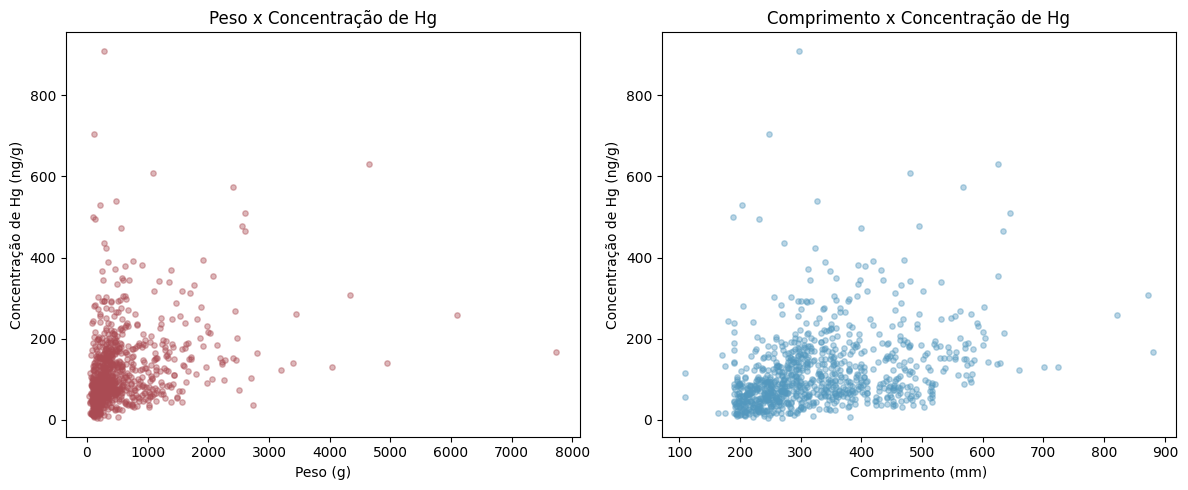

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Gráfico 1
axes[0].scatter(
    df_corrigido2["Peso (g)"],
    df_corrigido2["Concentração de Hg (ng/g)"], 
    alpha=0.4,
    s=15, 
    color="#AA4B53"
)
axes[0].set_title("Peso x Concentração de Hg")
axes[0].set_ylabel("Concentração de Hg (ng/g)")
axes[0].set_xlabel("Peso (g)")

# Gráfico 2
axes[1].scatter(
    df_corrigido2["Comprimento (mm)"],
    df_corrigido2["Concentração de Hg (ng/g)"],
    alpha=0.4, 
    s=15,
    color="#5398BE"
)
axes[1].set_title("Comprimento x Concentração de Hg")
axes[1].set_ylabel("Concentração de Hg (ng/g)")
axes[1].set_xlabel("Comprimento (mm)")

plt.tight_layout()
plt.show()

Os gráficos de dispersão indicam uma possível relação entre o peso, comprimento e a concentração de mercúrio, embora essa associação não seja muito forte. Ainda sim, esses resultados justificam a permanência desses atributos na indução do modelo.

Em segundo lugar, foi criado um gráfico que testa a relação entre a data de coleta e a concentração de mercúrio.

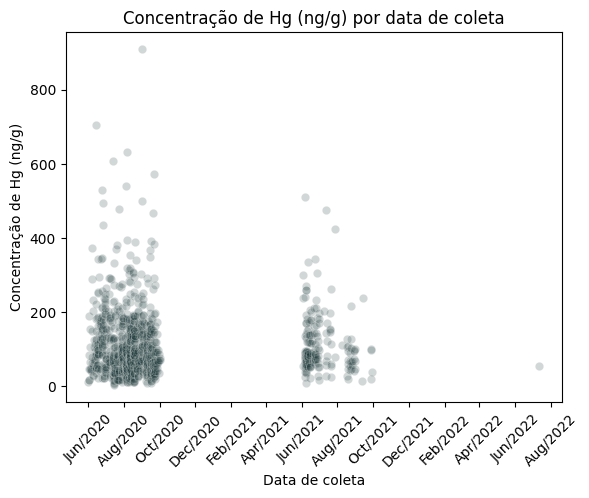

In [12]:
import matplotlib.dates as mdates

df_grafico_datas = df_corrigido2[["Data de coleta", "Concentração de Hg (ng/g)"]].sort_values("Data de coleta")

grafico_datas = sns.scatterplot(
    data=df_grafico_datas,
    x="Data de coleta",
    y="Concentração de Hg (ng/g)",
    alpha=0.2,
    color="#1C3738"
)

locator = mdates.MonthLocator(interval=2)              
formatter = mdates.DateFormatter('%b/%Y')    
grafico_datas.xaxis.set_major_locator(locator)
grafico_datas.xaxis.set_major_formatter(formatter)
plt.xticks(rotation=45)
plt.title("Concentração de Hg (ng/g) por data de coleta")

plt.show()

Através do gráfico é possível observar que não há uma relação clara entre a data de coleta e a concentração de mercúrio. Além disso, a maior parte das amostras foi coletada em 2020, o que pode dificultar a identificação de possíveis tendências ao longo do tempo. Levando esses fatores em consideração, a variável data de coleta não será utilizada nas etapas posteriores.

Também foram gerados três gráficos para analisar a relação entre atributos ligados ao local de coleta, como estado, região e local de coleta, e a concentração de mercúrio nas amostras.

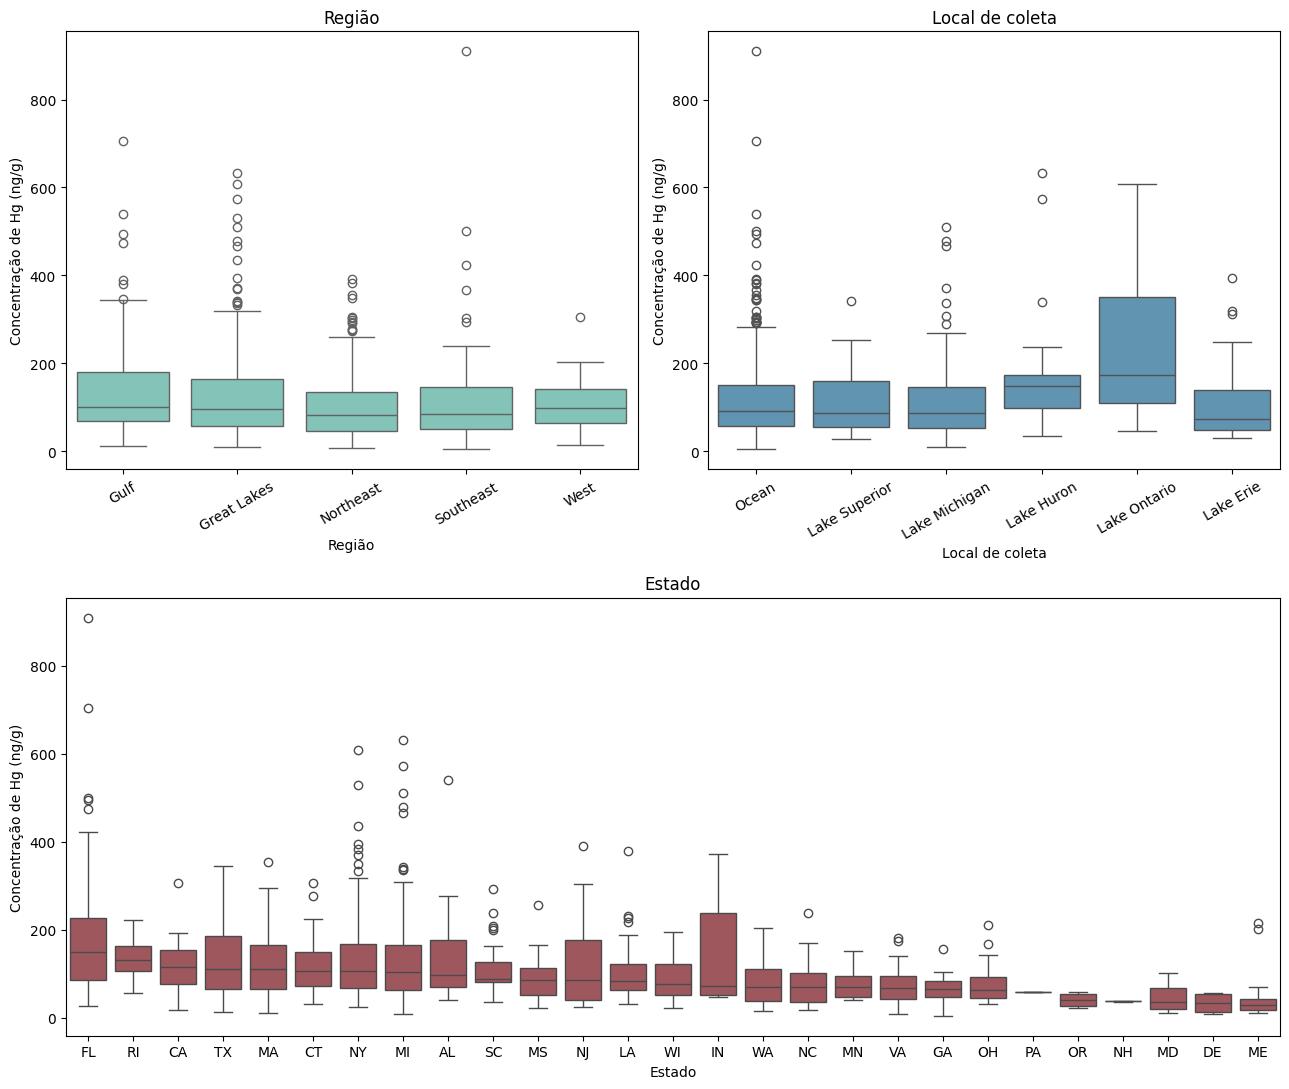

In [13]:
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(13, 11))
gs = gridspec.GridSpec(2, 2, figure=fig)

axes = [
    fig.add_subplot(gs[0, 0]),   
    fig.add_subplot(gs[0, 1]),   
    fig.add_subplot(gs[1, :]),   
]

# Gráfico 1
sns.boxplot(data=df_corrigido2,
x="Região", 
y="Concentração de Hg (ng/g)", 
ax=axes[0],
color="#79CDBF"
)
axes[0].set_title("Região")
axes[0].tick_params(axis="x", rotation=30)

# Gráfico 2
sns.boxplot(data=df_corrigido2,
x="Local de coleta", 
y="Concentração de Hg (ng/g)", 
ax=axes[1],
color="#5398BE"
)
axes[1].set_title("Local de coleta")
axes[1].tick_params(axis="x", rotation=30)

# Gráfico 3
ordem_estados = df_corrigido2.groupby("Estado")["Concentração de Hg (ng/g)"].median().sort_values(ascending=False).index

sns.boxplot(
data=df_corrigido2, 
x="Estado", 
y="Concentração de Hg (ng/g)", 
order=ordem_estados, 
color="#AA4B53"
)
axes[2].set_title("Estado")

plt.tight_layout()
plt.show()

Por meio dos gráficos, é possível observar que o local de coleta e o estado apresentam relação mais evidente com a concentração de mercúrio, enquanto as regiões possuem distribuições semelhantes e bastante sobrepostas. Além disso, o atributo região apresenta informações menos específicas do que o estado por exemplo. Levando esses fatores em consideração, a variável região não será utilizada nas etapas posteriores.

Por fim, foi gerado um gráfico que relaciona as espécies e a concentração de mercúrio mediana em cada uma. Note que, como apontado no `describe`, a coluna "**Espécie**" possui um valor de *unique* (quantidade de espécies diferentes) igual a 80. Muito provavelmente boa parte dessas espécies não deve representar um número muito grande de exemplos e, por isso, foi feita uma filtragem a fim de agrupar espécies que apareciam em menos de 10 exemplos em uma categoria só chamada "**Outras**". 

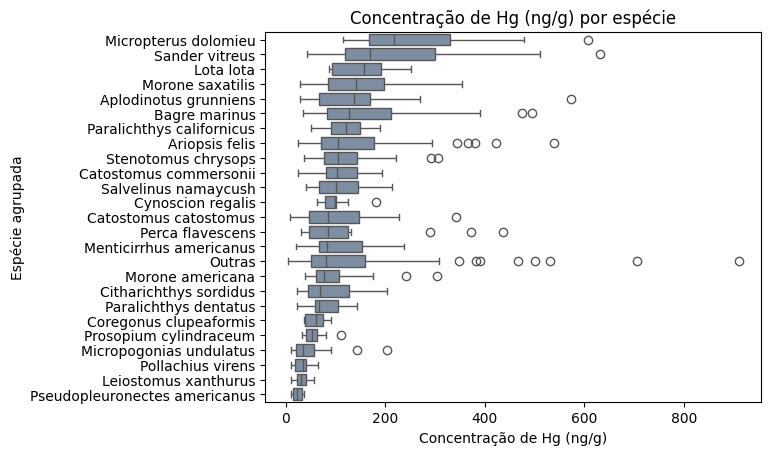

In [14]:
contagem_especies = df_corrigido2["Espécie"].value_counts()
especies_frequentes = contagem_especies[contagem_especies >= 10].index

df_corrigido2["Espécie agrupada"] = df_corrigido2["Espécie"].where(
    df_corrigido2["Espécie"].isin(especies_frequentes), "Outras"
)

ordem_especies = df_corrigido2.groupby("Espécie agrupada")["Concentração de Hg (ng/g)"].median().sort_values(ascending=False).index

sns.boxplot(
    data=df_corrigido2,
    y="Espécie agrupada",
    x="Concentração de Hg (ng/g)",
    order=ordem_especies,
    color="#778DA9"
)

plt.title("Concentração de Hg (ng/g) por espécie")
plt.show()

Através do gráfico, é possível observar uma relação clara entre a espécie e a concentração de mercúrio. Algumas espécies apresentam medianas e variações consideravelmente maiores, enquanto outras possuem concentrações mais baixas e homogêneas. Levando esses fatores em consideração, o atributo espécie será mantido nas etapas posteriores, pois pode contribuir significativamente para a previsão do target.

In [15]:
df_peixes = df_corrigido2.drop(["Região", "Espécie", "Data de coleta"], axis=1)

df_peixes

,Estado,Local de coleta,Concentração de Hg (ng/g),Comprimento (mm),Peso (g),Espécie agrupada
0,TX,Ocean,11.5,250.0,200.0,Micropogonias undulatus
1,MI,Lake Superior,190.0,434.0,540.0,Lota lota
2,TX,Ocean,17.5,164.0,80.0,Micropogonias undulatus
3,MI,Lake Superior,84.5,448.0,900.0,Catostomus catostomus
4,TX,Ocean,18.0,175.0,80.0,Micropogonias undulatus
...,...,...,...,...,...,...
905,MI,Lake Michigan,58.1,482.0,1080.0,Prosopium cylindraceum
906,MI,Lake Michigan,56.3,443.0,760.0,Prosopium cylindraceum
907,MI,Lake Michigan,46.8,465.0,920.0,Prosopium cylindraceum
908,MI,Lake Michigan,140.0,628.0,4950.0,Salvelinus namaycush


### *2.3. Divisão entre treino e teste*

Uma das estratégias necessárias para a indução e o teste de uma modelo preditivo trata-se da **estratégia de holdout**, também conhecida como **divisão em treino e teste** ou **train test split**. Ela consiste em reservar uma fração dos dados e usar apenas o restante deles para o treino do modelo. Após o treino, o modelo tenta prever os dados reservados para o teste e, com isso, é avaliado se o modelo tem um desempenho razoável quando tenta prever dados que não conhece. [3]

A divisão foi feita através do módulo `train_test_split` da biblioteca `SciKit-Learn`, na célula abaixo. Foi reservado $10\%$ dos dados para o teste, essa decisão foi tomada por conta do tamanho mediano do *dataset* (905 exemplos), de forma a manter uma quantidade razoavelmente grande para o teste do algoritmo.

In [16]:
from sklearn.model_selection import train_test_split

TAMANHO_TESTE = 0.1
SEMENTE_ALEATORIA = 12788

indices = df_peixes.index
indices_treino, indices_teste = train_test_split(
    indices,
    test_size=TAMANHO_TESTE,
    random_state=SEMENTE_ALEATORIA
)

df_treino = df_peixes.loc[indices_treino]
df_teste = df_peixes.loc[indices_teste]


### *2.4. Codificação e normalização dos dados*

Dois tipos de transformação de dados são a **codificação** e a **normalização**. Esses processos são de extrema importância para a indução de modelos, visto que atributos categóricos precisam ser transformados em número para que o algoritmo consiga interpretá-los e atributos numéricos precisam estar dentro da mesma escala para que um não predomine no cálculo de distância, por exemplo [7]. 

Nas células abaixo, a codificação foi feita por meio do `OneHotEncoder`, enquanto a normalização foi realizada utilizando de duas estratégias distintas: `StandardScaler` e `MinMaxScaler`, todos módulos da biblioteca `SciKit-Learn`.

In [17]:
from sklearn.preprocessing import OneHotEncoder

# Define as colunas que vão ser codificadas
colunas_cat_treino = df_treino[["Local de coleta", "Estado", "Espécie agrupada"]]
colunas_cat_teste = df_teste[["Local de coleta", "Estado", "Espécie agrupada"]]

# Codificação por OneHotEncoding
encoder = OneHotEncoder(sparse_output=False)
encoder.fit(colunas_cat_treino)

X_cat_treino = encoder.transform(colunas_cat_treino)
X_cat_teste = encoder.transform(colunas_cat_teste)

In [18]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

# Define as colunas que vão ser normalizadas
colunas_num_treino = df_treino[["Comprimento (mm)", "Peso (g)"]]
colunas_num_teste = df_teste[["Comprimento (mm)", "Peso (g)"]]

# Normalização por StandardScaler
normalizador_1 = StandardScaler()
normalizador_1.fit(colunas_num_treino)

X_num_treino = normalizador_1.transform(colunas_num_treino)
X_num_teste = normalizador_1.transform(colunas_num_teste)

# Normalização por MinMaxScaler
normalizador_2 = MinMaxScaler()
normalizador_2.fit(colunas_num_treino)

X_num_treino_mms = normalizador_2.transform(colunas_num_treino)
X_num_teste_mms = normalizador_2.transform(colunas_num_teste)


Para comparação de estratégias de normalização realizada na seção de Resultados, foram montadas duas versões do conjunto de atributos: com `StandardScaler` e com `MinMaxScaler`. Em todos os casos, os atributos categóricos já codificados continuam iguais e são combinados aos numéricos por meio da função `np.hstack`.

In [19]:
import numpy as np

# Junta o X codificado e normalizado por StandardScaler
X_treino_ss = np.hstack([X_cat_treino, X_num_treino])
X_teste_ss = np.hstack([X_cat_teste, X_num_teste])

# Junta o X codificado e normalizado por MinMaxScaler
X_treino_mms = np.hstack([X_cat_treino, X_num_treino_mms])
X_teste_mms = np.hstack([X_cat_teste, X_num_teste_mms])

# Y continua igual pro dois
y_treino = df_treino["Concentração de Hg (ng/g)"]
y_teste = df_teste["Concentração de Hg (ng/g)"]

### *2.5. Modelo baseline*

Para fins de comparação com modelos mais complexos, tem-se modelos básicos chamados de *baseline* ou *dummy*. Esses modelos são muito simples e **geralmente apresentam um desempenho baixo**. Qualquer modelo mais complexo que tiver um desempenho **pior** do que um *dummy* pode ser considerado um modelo muito ruim. [4]

A indução desse modelo foi feita a partir do `DummyRegressor` e a avaliação dele por meio dos módulos `mean_absolute_error` e `r2_score`, todos eles módulos da biblioteca `SciKit-Learn`.

In [20]:
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, r2_score

baseline = DummyRegressor()
baseline.fit(X_treino_ss, y_treino)
pred_baseline = baseline.predict(X_teste_ss)

print("MAE baseline:", mean_absolute_error(y_teste, pred_baseline))
print("R² baseline:", r2_score(y_teste, pred_baseline))

MAE baseline: 73.47692145692145
R² baseline: -0.004443793838727839


### *2.6. Modelo K-Nearest Neighbours* 

O algoritmo $k$**-vizinhos mais próximos** ($k$-NN) é um algoritmo de aprendizado de máquina baseado na hipótese que dados similares ocupam regiões próximas no espaço de entrada. O princípio de funcionamento de um modelo preditivo induzido por esse algoritmo é relativamente simples: ao receber um certo exemplo $x$, o algoritmo checa a distância desse exemplo com relação aos seus vizinhos. Quando estamos em um contexto de problemas de regressão, o valor predito pelo modelo será a média dos alvos dos $k$ vizinhos mais próximos do exemplo de entrada. [1]

Diferente de outros algoritmos de aprendizado de máquina, o $k$-NN é considerado um **algoritmo preguiçoso** pois, durante o treino, o modelo não ajusta nenhum coeficiente ou parâmetro interno, apenas memoriza o conjunto. Toda a computação de fato ocorre no momento da previsão, quando as distâncias até os vizinhos são calculadas [7]. Apesar disso, ao trabalhar com esse tipo de algoritmo é possível variar na escolha de hiperparâmetros como: a quantidade de vizinhos ($k$), a métrica de distância utilizada (euclidiana, manhattan, minkowski, chebyshev etc.) ou na escolha de incluir pesos de acordo com a distância. 

Para a realização desse trabalho, foram testados modelos $k$-NN sob um conjunto de 33 hiperparâmetros diferentes e duas estratégias de normalização distintas. O número de vizinhos variou entre os valores presentes na lista `valores_k` e as distâncias testadas foram a **euclidiana**, **manhattan** e **chebyshev**. Mesmo sendo um hiperparâmetro aplicável, a inclusão de pesos foi deixada de fora dos testes.

A célula abaixo testa as combinações de hiperparâmetros utilizando os dados normalizados por `StandardScaler`.

In [21]:
from sklearn.neighbors import KNeighborsRegressor

valores_k = [3, 5, 7, 9, 11, 15, 21, 31, 41, 51, 61]
metricas = ["euclidean", "manhattan", "chebyshev"]

resultados = []

for metrica in metricas:
    for k in valores_k:

        modelo = KNeighborsRegressor(n_neighbors=k, metric=metrica)
        modelo.fit(X_treino_ss, y_treino)
        pred_knn = modelo.predict(X_teste_ss)

        resultados.append({
            "Distância":metrica,
            "Nº vizinhos":k,
            "MAE":mean_absolute_error(y_teste, pred_knn),
            "R²":r2_score(y_teste, pred_knn)
        })

df_resultados_1 = pd.DataFrame(resultados)
df_resultados_1

,Distância,Nº vizinhos,MAE,R²
0,euclidean,3,56.794286,0.139064
1,euclidean,5,53.020615,0.248464
2,euclidean,7,49.366232,0.336608
3,euclidean,9,52.834347,0.282055
4,euclidean,11,54.249121,0.247826
5,euclidean,15,54.424806,0.215591
6,euclidean,21,54.814082,0.220684
7,euclidean,31,58.035732,0.198098
8,euclidean,41,60.005310,0.164963
9,euclidean,51,62.017223,0.155446


A célula abaixo repete o processo utilizando `MinMaxScaler` para fins de comparação.

In [22]:
valores_k = [3, 5, 7, 9, 11, 15, 21, 31, 41, 51, 61]
metricas = ["euclidean", "manhattan", "chebyshev"]

resultados = []

for metrica in metricas:
    for k in valores_k:

        modelo = KNeighborsRegressor(n_neighbors=k, metric=metrica)
        modelo.fit(X_treino_mms, y_treino)
        pred_knn = modelo.predict(X_teste_mms)

        resultados.append({
            "Distância":metrica,
            "Nº vizinhos":k,
            "MAE":mean_absolute_error(y_teste, pred_knn),
            "R²":r2_score(y_teste, pred_knn)
        })

df_resultados_2 = pd.DataFrame(resultados)
df_resultados_2

,Distância,Nº vizinhos,MAE,R²
0,euclidean,3,55.452527,0.174305
1,euclidean,5,52.953802,0.247494
2,euclidean,7,50.386641,0.327853
3,euclidean,9,51.448022,0.301829
4,euclidean,11,52.562148,0.263672
5,euclidean,15,52.797839,0.233166
6,euclidean,21,54.054851,0.247980
7,euclidean,31,58.550035,0.187662
8,euclidean,41,62.365706,0.128022
9,euclidean,51,63.539606,0.128218


## **3. Resultados e discussão**

Nesta seção são apresentados e discutidos os resultados obtidos a partir dos testes descritos na Metodologia. O modelo `DummyRegressor` obteve MAE de aproximadamente $73.48$ e R² de aproximadamente $0$. Esse resultado serve como referência mínima de desempenho. Qualquer modelo $k$-NN com desempenho pior do que esse indicaria que os hiperparâmetros ou atributos escolhidos pioram a previsão em vez de melhorá-la.

Os primeiros dois gráficos mostram a variação do valor de R² de acordo com o número de vizinhos e a métrica de distância utilizada, também são comparadas as duas estratégias de normalização aplicadas durante a transformação dos dados. Cada gráfico possui uma linha tracejada cinza que representa o desempenho do modelo baseline. Qualquer modelo que apresentar resultados piores do que o dessa linha pode ser considerado um modelo ruim. 

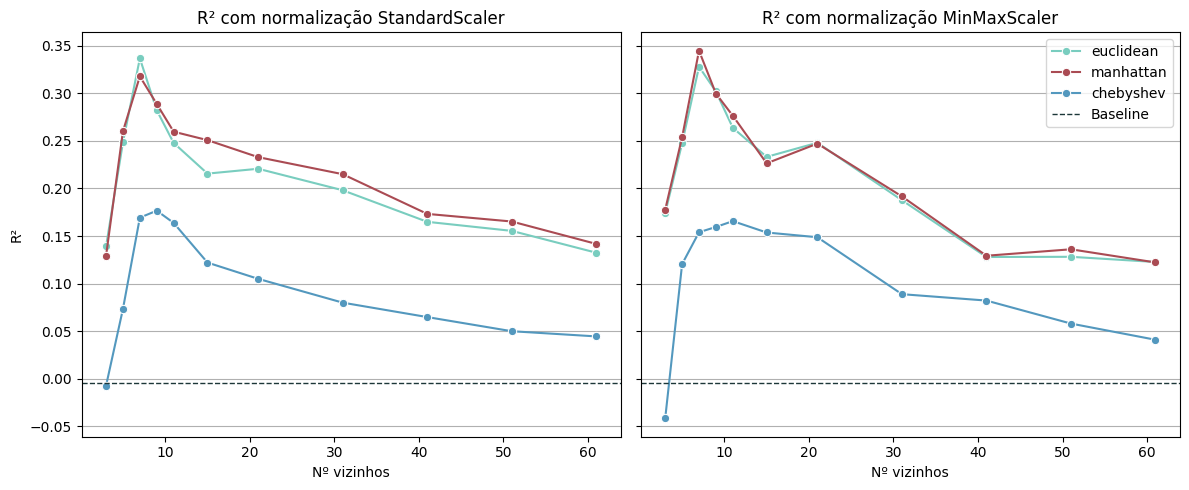

In [23]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# R² sem normalização
sns.lineplot(
    data=df_resultados_1,
    x="Nº vizinhos",
    y="R²",
    hue="Distância",
    marker="o",
    palette=["#79CDBF", "#AA4B53", "#5398BE"],
    ax=ax[0],
    legend=False
)
ax[0].set_title("R² com normalização StandardScaler")
ax[0].axhline(-0.004443793838727839, color="#1C3738", linestyle="--", linewidth=1, label="Baseline")
ax[0].grid(axis="y")

# R² normalizado
sns.lineplot(
    data=df_resultados_2,
    x="Nº vizinhos",
    y="R²",
    hue="Distância",
    marker="o",
    palette=["#79CDBF", "#AA4B53", "#5398BE"],
    ax=ax[1],
)
ax[1].set_title("R² com normalização MinMaxScaler")
ax[1].axhline(-0.004443793838727839, color="#1C3738", linestyle="--", linewidth=1, label="Baseline")
ax[1].grid(axis="y")
ax[1].legend(loc="upper right")

plt.tight_layout()
plt.show()

A partir desses gráficos é possível inferir que, em geral, o modelo $k$-NN induzido obteve desempenho consideravelmente maior do que o modelo baseline. Dentre os conjuntos de configurações utilizados, a distância euclidiana e a manhattan se destacam enquanto métricas de distância, especialmente com o número de vizinhos igual a 7. Em contrapartida, a distância chebyshev apresentou desempenho consistentemente inferior comparado às demais.
Comparando os dois `scalers`, observa-se que não possuem grande impacto no desempenho do modelo, com diferenças mínimas nos valores de R². O maior valor de R² ($\approx 0.344$) foi com o conjunto que utilizava distância manhattan e tinha número de vizinhos igual a 7, com normalização `MinMaxScaler`.

Os próximos dois gráficos mostram a variação do MAE de acordo com o número de vizinhos e a métrica de distância utilizada, também são comparadas as duas estratégias de normalização aplicadas durante a transformação dos dados. 

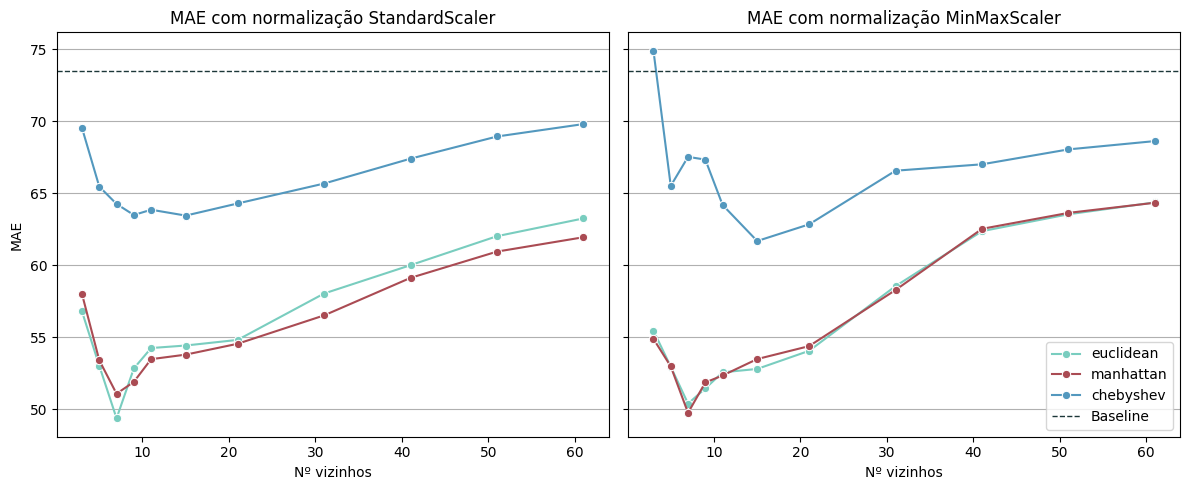

In [24]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# MAE sem normalização
sns.lineplot(
    data=df_resultados_1,
    x="Nº vizinhos",
    y="MAE",
    hue="Distância",
    marker="o",
    palette=["#79CDBF", "#AA4B53", "#5398BE"],
    ax=ax[0],
    legend=False
)
ax[0].set_title("MAE com normalização StandardScaler")
ax[0].axhline(73.47692145692145, color="#1C3738", linestyle="--", linewidth=1, label="Baseline")
ax[0].grid(axis="y")

# MAE normalizado
sns.lineplot(
    data=df_resultados_2,
    x="Nº vizinhos",
    y="MAE",
    hue="Distância",
    marker="o",
    palette=["#79CDBF", "#AA4B53", "#5398BE"],
    ax=ax[1]
)
ax[1].set_title("MAE com normalização MinMaxScaler")
ax[1].axhline(73.47692145692145, color="#1C3738", linestyle="--", linewidth=1, label="Baseline")
ax[1].grid(axis="y")
ax[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

Por meio desses gráficos é observável que os mesmos conjuntos de hiperparâmetros que apresentaram um bom desempenho no gráfico de R² também apresentam um baixo MAE. As combinações que utilizaram como métrica a distância euclidiana e a manhattan continuam em destaque, enquanto as configurações com distância chebyshev seguem com pior desempenho. O número de vizinhos igual a 7 continua sendo o mais eficaz, com destaque para a combinação de distância euclidiana e normalização `StandardScaler`, que obteve o menor MAE ($\approx 49.37$) entre todas as configurações testadas.

Por fim, o conjunto de hiperparâmetros final escolhido foi o que continha distância euclidiana combinada com o número de vizinhos igual a 7, normalizado por meio do `StandardScaler`, por apresentar o menor MAE entre todas as configurações testadas.

O gráfico abaixo apresenta a comparação entre os valores reais e os valores previstos pelo modelo final para o conjunto de teste.

C:\Users\giovanni2610060\AppData\Local\Temp\ipykernel_44532\3762749944.py:14: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r--" (-> color='r'). The keyword argument will take precedence.
  plt.plot(


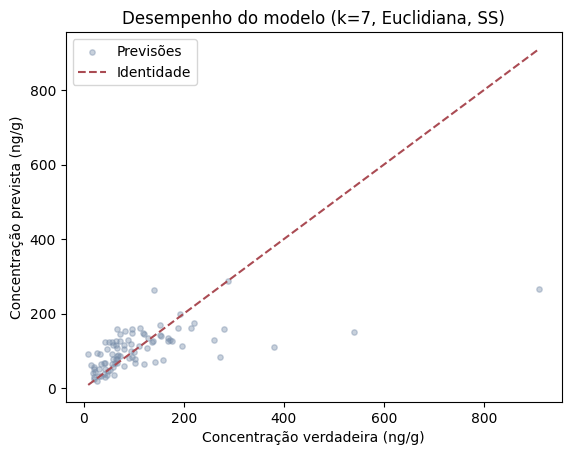

In [25]:
modelo_final = KNeighborsRegressor(n_neighbors=7, metric="euclidean")
modelo_final.fit(X_treino_ss, y_treino)
pred_final = modelo_final.predict(X_teste_ss)

plt.scatter(
    y_teste, 
    pred_final, 
    alpha=0.4, 
    s=15,
    label="Previsões",
    color="#778DA9"
)

plt.plot(
    [y_teste.min(), y_teste.max()],
    [y_teste.min(), y_teste.max()],
    "r--", 
    label="Identidade",
    color="#AA4B53"
)

plt.xlabel("Concentração verdadeira (ng/g)")
plt.ylabel("Concentração prevista (ng/g)")
plt.title("Desempenho do modelo (k=7, Euclidiana, SS)")
plt.legend()

plt.show()

É possível observar que, para concentrações de mercúrio mais baixas (abaixo de ~200 ng/g), as previsões se aproximam razoavelmente bem da reta que representa a previsão exata. Entretanto, para concentrações mais altas, o modelo tende a subestimar os valores reais — um comportamento esperado em algoritmos baseados em vizinhança como o $k$-NN, já que a previsão é uma média dos vizinhos mais próximos e a maioria das amostras do dataset possui concentrações baixas, "puxando" a previsão de casos atípicos em direção à média geral.

## **4. Conclusões e principais aprendizados**

### *4.1. Conclusão*
O modelo $k$-NN induzido, na configuração final (k=7, distância euclidiana, dados normalizados por `StandardScaler`), apresentou desempenho superior ao baseline (MAE de $49.37$ contra $73.48$, e R² de $0.337$ contra aproximadamente $0$), confirmando que os atributos escolhidos (peso, comprimento, espécie, estado e local de coleta) carregam informação real sobre a concentração de mercúrio em peixes, ainda que de forma parcial.

Dentre os hiperparâmetros testados, valores de $k$ próximos de 7 apresentaram o melhor equilíbrio, enquanto a distância de Chebyshev apresentou desempenho consistentemente inferior às demais métricas. Apesar da melhora em relação ao baseline, o modelo explica apenas cerca de um terço da variação da concentração de mercúrio, indicando que outros fatores não capturados pelo dataset provavelmente têm papel relevante na concentração de mercúrio em peixes.

Uma limitação observada na análise do gráfico de desempenho do modelo final foi a subestimação de concentrações altas de mercúrio. Esse comportamento é esperado em algoritmos baseados em vizinhança quando a distribuição do `target` é muito concentrada em uma faixa específica, a previsão tende a ser "puxada" para a média pelos seus vizinhos mais próximos. Entretanto, essa limitação se torna especialmente perigosa em contextos como esse, visto que subestimar a quantidade de mercúrio em um peixe pode ter consequências mais sérias do que superestimar esse valor.

### *4.2. Principais aprendizados*

Os principais aprendizados obtidos por meio dessa tarefa foram muitos. Uma quantidade absurda de conceitos estudados em sala, de forma principalmente teórica, foi aplicada de forma prática durante o desenvolvimento dessa atividade. Alguns dos conceitos que foram solidificados durante a formulação desse trabalho são: a importância de etapas como o *train test split*, como diferentes normalizações podem afetar o desempenho de modelos preditivos e a aplicação de análises estatísticas descritivas na escolha dos atributos, entre outros. Também houve um amadurecimento no que diz respeito à parte de programação como melhor entendimento do uso das bibliotecas: `SciKit-Learn`, `Pandas`, `NumPy`, `Seaborn` e `Matplotlib`.

## **Nota sobre uso de IA**

Durante o desenvolvimento deste trabalho foram utilizadas as IAs **Claude (Anthropic)** e **Copilot (Microsoft)** em diferentes frentes. Algumas de suas aplicações foram: ajuda na busca do *dataset*, formulação do código de gráficos, auxílio no uso de bibliotecas como `Pandas`, `NumPy` e `SciKit-Learn`, esclarecimento de dúvidas conceituais sobre aprendizado de máquina, depuração de erros no código e revisão gramatical dos textos em Markdown. Além disso, a IA foi utilizada como uma forma de validação de ideias e decisões tomadas ao longo do trabalho e também fez uma revisão ao final dele.


## **Referências**

[1] CASSAR, Daniel Roberto. ATP-203 2.1 - Aprendizado de máquina, k-NN e métricas. Notebook de aula, disciplina de Probabilidade e Estatística, Ilum, Escola de Ciência, 2026. Disponibilizado pelo docente.

[2] CASSAR, Daniel Roberto. LMA-203 1.0 - . Notebook de aula, disciplina de Probabilidade e Estatística, Ilum, Escola de Ciência, 2026. Disponibilizado pelo docente.

[3] CASSAR, Daniel Roberto. ATP-203 2.2 - Divisão de dados em treino e teste. Notebook de aula, disciplina de Probabilidade e Estatística, Ilum, Escola de Ciência, 2026. Disponibilizado pelo docente.

[4] CASSAR, Daniel Roberto. ATP-203 3.0 - Modelo linear e baseline. Notebook de aula, disciplina de Probabilidade e Estatística, Ilum, Escola de Ciência, 2026. Disponibilizado pelo docente.

[5] UNITED STATES ENVIRONMENTAL PROTECTION AGENCY (EPA). National Coastal Condition Assessment (NCCA): mercury in fish fillet plug tissue samples, 2020-2022 (ncca20_hg_fishplug.csv). Washington, D.C.: U.S. EPA, 2024. Disponível em: https://www.epa.gov/national-aquatic-resource-surveys/data-national-aquatic-resource-surveys. Acesso em: 5 set. 2026.

[6] AGENCY FOR TOXIC SUBSTANCES AND DISEASE REGISTRY (ATSDR). ToxFAQs for Mercury. Atlanta: U.S. Department of Health and Human Services, 2022. Disponível em: https://wwwn.cdc.gov/TSP/ToxFAQs/ToxFAQsDetails.aspx?faqid=113&toxid=24. Acesso em: 20 set. 2026.

[7] FACELI, Katti; LORENA, Ana Carolina; GAMA, João; et al. Inteligência Artificial: uma abordagem de Aprendizado de Máquina. 2. ed. Rio de Janeiro: LTC, 2021.